# Molecular Dynamics of HDAC8

- **Author**: Yamila Timmer
- **Date**: 29-01-2026

## Imports & loading universe objects

In [28]:
# imports
import MDAnalysis as mda
from MDAnalysis.analysis import rms, distances
from MDAnalysis.analysis.dssp import DSSP, translate
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm


In [3]:
# Create universe objects
WT_0_complete = mda.Universe("../variants/WT/WT-0-ion.pdb", "../variants/WT/WT-0-ion.xtc")
WT_1_complete = mda.Universe("../variants/WT/WT-1-ion.pdb", "../variants/WT/WT-1-ion.xtc")
WT_2_complete = mda.Universe("../variants/WT/WT-2-ion.pdb", "../variants/WT/WT-2-ion.xtc")

WT_0 = mda.Universe("../variants/WT/WT-0-last-50ns-avg.pdb", "../variants/WT/WT-0-last-50ns.xtc")
WT_1 = mda.Universe("../variants/WT/WT-1-last-50ns-avg.pdb", "../variants/WT/WT-1-last-50ns.xtc")
WT_2 = mda.Universe("../variants/WT/WT-2-last-50ns-avg.pdb", "../variants/WT/WT-2-last-50ns.xtc")

G320R_0 = mda.Universe("../variants/G320R/G320R-0-last-50ns-avg.pdb",
                       "../variants/G320R/G320R-0-last-50ns.xtc")

G320R_1 = mda.Universe("../variants/G320R/G320R-1-last-50ns-avg.pdb",
                       "../variants/G320R/G320R-1-last-50ns.xtc")
G320R_2 = mda.Universe("../variants/G320R/G320R-2-last-50ns-avg.pdb",
                       "../variants/G320R/G320R-2-last-50ns.xtc")

H180R_0 = mda.Universe("../variants/H180R/H180R-0-last-50ns-avg.pdb",
                       "../variants/H180R/H180R-0-last-50ns.xtc")
H180R_1 = mda.Universe("../variants/H180R/H180R-1-last-50ns-avg.pdb",
                       "../variants/H180R/H180R-1-last-50ns.xtc")
H180R_2 = mda.Universe("../variants/H180R/H180R-2-last-50ns-avg.pdb",
                       "../variants/H180R/H180R-2-last-50ns.xtc")

H334R_0 = mda.Universe("../variants/H334R/H334R-0-last-50ns-avg.pdb",
                       "../variants/H334R/H334R-0-last-50ns.xtc")
H334R_1 = mda.Universe("../variants/H334R/H334R-1-last-50ns-avg.pdb",
                       "../variants/H334R/H334R-1-last-50ns.xtc")
H334R_2 = mda.Universe("../variants/H334R/H334R-2-last-50ns-avg.pdb",
                       "../variants/H334R/H334R-2-last-50ns.xtc")

T311M_0 = mda.Universe("../variants/T311M/T311M-0-last-50ns-avg.pdb",
                       "../variants/T311M/T311M-0-last-50ns.xtc")
T311M_1 = mda.Universe("../variants/T311M/T311M-1-last-50ns-avg.pdb",
                       "../variants/T311M/T311M-1-last-50ns.xtc")
T311M_2 = mda.Universe("../variants/T311M/T311M-2-last-50ns-avg.pdb",
                       "../variants/T311M/T311M-2-last-50ns.xtc")

# Cropped objects, with PDB containing an avg "snapshot" of final 50ns of trajectory
WT_avg = mda.Universe("../variants/WT/WT-2-last-50ns-avg.pdb")
G320R_avg = mda.Universe("../variants/G320R/G320R-1-last-50ns-avg.pdb")
H180R_avg = mda.Universe("../variants/H180R/H180R-2-last-50ns-avg.pdb")
H334R_avg = mda.Universe("../variants/H334R/H334R-1-last-50ns-avg.pdb")
T311M_avg = mda.Universe("../variants/T311M/T311M-1-last-50ns-avg.pdb")

# Objects used for determining secondary structure
WT_0_secondary = mda.Universe("../variants/WT/WT-0-ion.tpr", "../variants/WT/WT-0-ion.xtc").select_atoms('resid 1-376')
WT_1_secondary = mda.Universe("../variants/WT/WT-1-ion.tpr", "../variants/WT/WT-1-ion.xtc").select_atoms('resid 1-376')
WT_2_secondary = mda.Universe("../variants/WT/WT-2-ion.tpr", "../variants/WT/WT-2-ion.xtc").select_atoms('resid 1-376')

C:\Users\yamil\AppData\Local\Programs\Python\Python314\Lib\site-packages\MDAnalysis\coordinates\XDR.py:261: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(
C:\Users\yamil\AppData\Local\Programs\Python\Python314\Lib\site-packages\MDAnalysis\topology\PDBParser.py:372: UserWarning: Unknown element  found for some atoms. These have been given an empty element record. If needed they can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn(wmsg)
C:\Users\yamil\AppData\Local\Programs\Python\Python314\Lib\site-packages\MDAnalysis\topology\PDBParser.py:402: UserWarning: Unknown entry C encountered in formal charge field. This likely indicates that the PDB file is not fully standard compliant. The formalcharges attribute will not be populated.
  warnings.warn(wmsg)
C:\Users\yamil\AppData\Local\Programs\Python\Python314\Lib\site-packages\MDAnalysis\topology\PDBParser.py:402: UserWarning: Unkno

## Research Question
In this notebook, a molecular dynamics approach was used to gain a better understanding of the functional and structural changes of HDAC8 caused by mutations. Four mutations of HDAC8 were analyzed, which are known to be associated with Cornelia de Lange Syndrome. I chose this subject because I will be analyzing data regarding a protein complex, of which a subunit (SMC3) is deacetylated by HDAC8 under normal conditions. The research question I hope to answer is _what the effects of the selected mutations are on the structure and dynamics of HDAC8 and how this relates to a (partial) loss-of-function._

## Biological Background
Cornelia de Lange Syndrome (CdLS) is a rare, but impactful, genetic disorder, named after the Dutch paediatrician who first described it in 1933 (De Lange, 1933). The disorder affects multiple domains, including the physical, such as the development of facial structure and limbs, the cognitive, with the majority displaying an intellectual disability, and the behavioral, including self-injurious or repetitive behavior (Kline et al., 2018). CdLS is caused by defects in the cohesin protein complex or in supporting proteins, also known as cohesinopathies (Kline et al., 2018). To date, various mutations of HDAC8 have been found associated with CdLS. CdLS cases caused by HDAC8 mutations are all sheltered under the subtype CdLS5.

Post-translational modification of histones is a largely studied field contributing to a better understanding of transcriptional regulation. One such form of modification is acetylation, which involves the donation of an acetyl group (-COCH₃) from acetyl coenzyme A (Ac-CoA) to a specific site on a protein. There are two distinct forms, acetylation of the N-terminal and acetylation of the ε-amino group of lysine residues (Drazic et al., 2016). Whereas histone acetyltransferases can donate an acetyl group to a target site in a protein, histone deacetylases can remove these groups. Histone acetylation determines transcriptional activity; hyperacetylation is associated with increased activity, while hypoacetylation is associated with repression of activity (De Ruijter et al., 2003). (de)Acetylation can also take place in other protein structures. HDAC8 was found to deacetylate K105 and K106 of SMC3 (Deardorff et al., 2016). Together with other proteins (SMC1, RAD21, and STAG), SMC3 forms the ring-shaped cohesin complex. This complex plays a vital role in gene regulation; it also ensures sister chromatid cohesion during the cell cycle to prevent sister chromatids from separating before anaphase (Deardorff et al., 2012). Deacetylation of SMC3 during anaphase is essential, as only deacetylated SMC3 can be recycled to form new cohesin complexes. Conversely, SMC3 acetylation during S‑phase is required to establish cohesion and ensure proper cohesin function (Deardorff et al., 2012).

17 missense mutations in HDAC8 have been identified in relation to CdLS (Decroos et al., 2015), of those 4 are analysed in this notebook: H180R, T311M, H334R, and G320R.

## Structure HDAC8
HDAC8 is a relatively small enzyme, consisting of 377 residues. It only contains one distinctive domain, which is the histone deacetylase at position 14-324 (colored yellow). The enzyme requires one zinc ion, as it is zinc-dependent, the ion can be seen as having a central position in the protein. All locations of mutations that will be analyzed are coloured red. Three of them are in the histone deacetylase region, and one lies outside. Locations outside of the histone deacetylase domain are colored blue.

## Mutations
The table below contains all mutations that are analyzed in this notebook. All of these mutations are known to be associated with CdLS5, a subtype of CdLS that is caused by mutations in HDAC8. The table shows the change in residue and at what position it takes place. It also shows the percentage of catalytic activity compared to the wild type and the distance between the mutation and the Zn ion.

The remaining catalytic activity in comparison to the WT differs per variant. H180R seems not to have any remaining catalytic activity, the reason for this is likely because residue 180 plays an important role in catalytic activity (also see the information on the active site below). Having an important residue change can lead to complete dysregulation of the active site. The distance of the mutated residue to the Zn ion was calculated under the assumption that the closer the mutation is to the active site, the more likely it has an impact on catalytic activity. The distance calculation was done in the distance analysis section. The mutation closest to the Zn ion only has a distance of 5.8Å (the size of 1 to 2 residues). The hypothesis that a mutated residue with a close distance to Zn is likely to have an effect on catalytic activity seems to uphold here, as HDAC8 with an H180R mutation has 0% catalytic activity. The T311M mutation is around double as far away from Zn as H180R, still here too, the catalytic activity seems drastically effected, with 6% of activity remaining. G320R is more than double as far away from Zn as T311M, but actually has a worse catalytic outcome, of only 1.5/2% of activity remaining. 22.59Å is a distance of around 6-7 residues, so it is still decently close to the active site, however. H334R is the mutation with the most distance, with 30.7Å to the Zn ion. It is possible that the sheer distance between the mutation and the active site could have made the mutation not as impactful on catalytic activity.

| Mutation | Position | Cat. Activity               | Dist to Zn  |
| -------- | -------- |-----------------------------|-------------|
| H > R    | 180      | 0% (Decroos et al., 2015)   | 5.8Å        |
| T > M    | 311      | 6% (Decroos et al., 2014)   | 10.5Å       |
| G > R    | 320      | 1.5-2% (Osko et al., 2020)  | 22.59Å      |
| H > R    | 334      | 91% (Decroos et al., 2014)  | 30.7Å       |

![](imgs/HDAC8-structure.gif)

### Active site

The active site of HDAC8 has a narrow tunnel shape, leading to the catalytic machinery. By observing these two structures, vital components of the active site can be identified. F152, F208, H180, G151, M274, and Y306 make up the structure of the tunnel (Somoza et al., 2004). Central to the active site lies a zinc ion, bound to carboxylate oxygens of D178 and D267 (Somoza et al., 2004). H180, D178, and D267 play a significant role in coordinating the Zn$^{2+}$ ion (Vannini et al., 2004).

![](imgs/catalytic_site_HDAC8.png)

The tunnel shape can clearly be observed when displaying the protein with `show surface, all`.

![](imgs/HDAC8_tunnel.png)

Components vital to the catalytic activity of HDAC8 are situated close to the central Zn${2+}$. His142, which is coordinated by Asp176, and His143, which is coordinated by Asp 183, also seem to play an important role. Finnin et al. (1999) proposed that the His142-Asp176 dyad abstracts a proton from water, thereby facilitating the nucleophilic attack that leads to the deacetylation of the lysine residue on the protein. The proposed role of His143-Asp183 is to donate a proton to the amine during the breakdown of the tetrahedral structure that exists during nucleophilic attack. The image below displays the proposed catalytic activity of HDAC8 (Decroos et al.,2015).

![](imgs/HDAC8_reaction.jpeg)


## Comparing alphafold variants (and maybe known PDB's)

Using AlphaFold, molecular structure was predicted for 5 different variants of HDAC8. Including the wildtype with no mutations and 4 known mutations that are associated to Cornelia de Lange syndrome. For each variant, 3 predicted structures are compared, to compare and see if AlphaFold predictions for molecular structure of (mutated) SMC3 are consistent.

### G320R
Loading all AlphaFold predictions and aligning them to see if AlphaFold predictions are consistent:
```
load G320R-0.pdb
load G320R-1.pdb
load G320R-2.pdb

alignto G320R-0
```
Below the result can be seen, the different predictions are clearly very closely related, with only minor differences
 in structure. The zinc ions seems to be completely overlapping for all three predictions. In the image, prediction 1
  is green,
 prediction 2 is
 blue and
 prediction 3 is pink.
The RMSD of G320R-0/G320R-1 = 0.472 and the RMSD of G320R-0/G320R-2 = 0.392

![](imgs/G320R-align.png)


## Run settings for simulation

As the AlphaFold predictions seem to be consistent, further analyzing can be done by simulating molecular dynamics. This is done by computing 250ns of protein movement using GROMACS (Bekker et al., 1993). This software simulates protein movement in a simulated repetitive space surrounding the protein, filled with water. Various forcefields can be used to calculate molecular dynamics, in this notebook CHARMM (Brooks et al., 2009) was chosen, as it is more suited for calculations involving ions, as opposed to the AMBER forcefields (Case et al., 2025), where it is necessary to immobilize the ion.

[gromit](https://github.com/marrink-lab/gromit), a wrapper for GROMACS was used. The wrapper includes a bash script that will fully go through all the steps of GROMACS, which makes it a lot easier to generate MD output. It was ran with the following command:

`gromit.sh -f $base.pdb -ff $FF -equil 0.01 -pre 0.01 -time 250 -d 2 \
     --mdp-nstxout=0 --mdp-nstpcouple=100 --mdp-nsttcouple=100 --mdp-nstenergy=100 --mdp-constraints=h-bonds --mdp-nstlist=50 -stop TPR`

- `-f`: input coordinate file (PDB)
- `-ff`: what forcefield to use
- `-equil`: equilibration run time (ns)
- `-pre`: preproduction run time (ns)
- `-time`: production run time (ns)
- `-d`: distance between images over PBC
- `--mdp-nstxout`: number of steps that elapse between writing coordinates to the output trajectory file (trr)
- `--mdp-nstpcouple`: the interval between steps that couple the pressure
- `--mdp-nsttcouple`: the interval between steps that couple the temperature
- `--mdp-nstenergy`: number of steps that elapse between writing energies to the energy file (edr)
- `--mdp-constraints`: controls which bonds in the topology will be converted to rigid holonomic constraints
- `--mdp-nstlist`: interval between steps that update the neighbor list

The following command was used to start the 250ns run:
`gmx mdrun -deffnm $base-MD -pin on -pinstride 0 -ntmpi 1 -npme 0 -nb gpu -ntomp 12 -gpu_id 0 -bonded gpu -update gpu`

- `-deffnm`: sets the default filename for all file options
- `-pin`: whether mdrun should try to set thread affinities
- `-pinstride`: pinning distance in logical cores for threads, use 0 to minimize the number of threads per physical core
- `-ntmpi`: number of thread-MPI threads to start
- `-npme`: number of separate ranks to be used for PME
- `-nb`: calculate non-bonded interactions on
- `-ntomp`: number of OpenMP threads per MPI rank to start
- `-gpu_id`: list of GPU device id-s to use, specifies the per-node PP rank to GPU mapping
- `-bonded`:
- `-update`:

More info on usage of GROMACS can be found [https://manual.gromacs.org/current/index.html](here)


For later analysis, a subset of the trajectory will be used, where only the final 50ns is analysed, after the protein has unfolded from its crystallized structure. All input files that are used in this notebook can be generated easily using GROMACS output, using [the snakemake pipeline I made](https://github.com/YamilaTimmer/molecular-dynamics-HDAC8/tree/main/workflow). All that has to be done is adjust the [config file](https://github.com/YamilaTimmer/molecular-dynamics-HDAC8/blob/main/workflow/config.yaml) to the data directory. Each variant needs to have its own folder in this directory, with GROMACS output. In each folder an output folder will be generated with the further processed data. Including the pdb/trajectory without solvent and reduced simulations to the final 50ns. Below is a description of how to do all these steps manually, if needed.

### Removing solvent
In order to visualize the molecular movement of HDAC8 and its mutated forms, first all hydrogen molecules and ions must be removed, with the exception of the cofactor Zn${2+}$ ion. To do this, an index file needs to be created, for the second WT prediction this would be:

`gmx make_ndx -f WT-1.gro -o index.ndx`

This gives the following selection:

```
There are:   377    Protein residues
There are:     1        Ion residues
Analysing Protein...

  0 System              :  5806 atoms
  1 Protein             :  5805 atoms
  2 Protein-H           :  2936 atoms
  3 C-alpha             :   377 atoms
  4 Backbone            :  1131 atoms
  5 MainChain           :  1509 atoms
  6 MainChain+Cb        :  1853 atoms
  7 MainChain+H         :  1869 atoms
  8 SideChain           :  3936 atoms
  9 SideChain-H         :  1427 atoms
 10 Prot-Masses         :  5805 atoms
 11 non-Protein         :     1 atoms
 12 Ion                 :     1 atoms

 nr : group      '!': not  'name' nr name   'splitch' nr    Enter: list groups
 'a': atom       '&': and  'del' nr         'splitres' nr   'l': list residues
 't': atom type  '|': or   'keep' nr        'splitat' nr    'h': help
 'r': residue              'res' nr         'chain' char
 "name": group             'case': case sensitive           'q': save and quit
 'ri': residue index
```

Select 0 and an index file containing the main system (protein + ion) is created. Now when making a reduces trajectory file and pdb file this index can be used.


For each output folder of GROMACS the command below can be run, as only one MD.tpr and MD.xtc file exist per folder. This wil generate a trajectory file containing only the simulated movement of the atoms of the protein and the Zn2+ ion.

`gmx trjconv -s *MD.tpr -f *MD.xtc -pbc mol -o protein_ion.xtc -n index.ndx -center`

Select 0 for group selection and for centering selection.

```
Select group for output
Group     0 (         System) has  5806 elements
Group     1 (        Protein) has  5805 elements
Group     2 (      Protein-H) has  2936 elements
Group     3 (        C-alpha) has   377 elements
Group     4 (       Backbone) has  1131 elements
Group     5 (      MainChain) has  1509 elements
Group     6 (   MainChain+Cb) has  1853 elements
Group     7 (    MainChain+H) has  1869 elements
Group     8 (      SideChain) has  3936 elements
Group     9 (    SideChain-H) has  1427 elements
Group    10 (    Prot-Masses) has  5805 elements
Group    11 (    non-Protein) has     1 elements
Group    12 (            Ion) has     1 elements
Group    13 (    Protein_Ion) has  5806 elements
```

Besides an adjusted trajectory file, an adjusted pdb is also needed. This can be done by 'dumping' the first frame of the trajectory with:

`gmx trjconv -s *MD.tpr -f protein_ion.xtc -pbc mol -o protein-ion.pdb -dump 0 -n index.ndx -center`

Make subset version of tpr (no solvent)
```
gmx convert-tpr -s ../../G320R-1/G320R-1-MD.tpr -n ../../index.ndx -o G320R-1-ion.tpr
```

Again select group 0 for both selections.

### Reducing trajectory to final 50ns

The simulations are 5000 frames of 0.5ns each (total 250ns). We want to only look at the final 50ns, as the protein will have folded out from crystallized structure. To do that we can use the code below. -b and -e are the start and endpoint measured in picoseconds.

```
gmx trjconv -f [variant].xtc -o final_50ns.xtc -b 200000 -e 250000
```

Now the average configuration can be determined for each residue

```
gmx rmsf -f final_50ns.xtc -s [variant].tpr -ox avg_structure.pdb
```


Some of the MD simulations seem to have timed out before reaching 250ns (possibly due to SLURM time limit). GROMACS makes a checkpoint every 15 minutes and simulations can be resumed from the last checkpoint using

```
gmx mdrun -v -deffnm WT-1-MD -cpi WT-1-MD.cpt
```

## Analysis of Variants

The simulation can now be viewed in PyMol. The protein needs to be fitted, as it moves too much to properly analyze it. Below it is fitted on all alpha carbons, except for those in loops (as they tend to move a lot).

```
load WT-ion.pdb, WT
load WT-ion.xtc, WT
intra_fit WT and name CA and not ss l
```


### Secondary Structures
Below the average secondary structures are determined, meaning the average form residues take over the entirety of the simulation. The results can be used to annotate our RMSF graphs.


In [4]:
def calculate_RMSF(universe):

    c_alphas = universe.select_atoms('protein and name CA')
    R = rms.RMSF(c_alphas).run()

    return c_alphas, R

c_alphas_WT_0_complete, R_WT_0_complete = calculate_RMSF(WT_0_complete)
c_alphas_WT_1_complete, R_WT_1_complete = calculate_RMSF(WT_1_complete)
c_alphas_WT_2_complete, R_WT_2_complete = calculate_RMSF(WT_2_complete)

c_alphas_WT_0, R_WT_0 = calculate_RMSF(WT_0)
c_alphas_WT_1, R_WT_1 = calculate_RMSF(WT_1)
c_alphas_WT_2, R_WT_2 = calculate_RMSF(WT_2)

c_alphas_G320R_0, R_G320R_0 = calculate_RMSF(G320R_0)
c_alphas_G320R_1, R_G320R_1 = calculate_RMSF(G320R_1)
c_alphas_G320R_2, R_G320R_2 = calculate_RMSF(G320R_2)

c_alphas_H180R_0, R_H180R_0 = calculate_RMSF(H180R_0)
c_alphas_H180R_1, R_H180R_1 = calculate_RMSF(H180R_1)
c_alphas_H180R_2, R_H180R_2 = calculate_RMSF(H180R_2)

c_alphas_H334R_0, R_H334R_0 = calculate_RMSF(H334R_0)
c_alphas_H334R_1, R_H334R_1 = calculate_RMSF(H334R_1)
c_alphas_H334R_2, R_H334R_2 = calculate_RMSF(H334R_2)

c_alphas_T311M_0, R_T311M_0 = calculate_RMSF(T311M_0)
c_alphas_T311M_1, R_T311M_1 = calculate_RMSF(T311M_1)
c_alphas_T311M_2, R_T311M_2 = calculate_RMSF(T311M_2)


In [5]:
# Average secondary structure
secondary_structures = {}

for variant in [WT_0_secondary, WT_1_secondary, WT_2_secondary]:
    long_run = DSSP(variant).run()
    mean_secondary_structure = translate(long_run.results.dssp_ndarray.mean(axis=0))
    secondary_structures[variant] = ''.join(mean_secondary_structure)

The average secondary structures are determined by "merging" the 3 together, based on structures they have in common. If minimally 2 of the structures have a specific secondary structure (helix/sheet/loop), then that one will be added to a new joined sequence.

In [6]:
avg_secondary = []
for a, b, c in zip(secondary_structures[WT_0_secondary],
                   secondary_structures[WT_1_secondary],
                   secondary_structures[WT_2_secondary]):
    triplet = [a, b, c]
    if triplet.count('H') >= 2:
        avg_secondary.append('H')
    elif triplet.count('E') >= 2:
        avg_secondary.append('E')
    else:
        avg_secondary.append('-')

avg_secondary_WT = ''.join(avg_secondary)

### Calculating RMSF

In this section I will calculate and compare the root mean square fluctuation (RMSF) of the WT of HDAC8 and its variants. I do this to see if any areas of the protein gain more mobility after mutating, compared to the wildtype, possibly inhibiting its normal functioning as catalytically active protein.

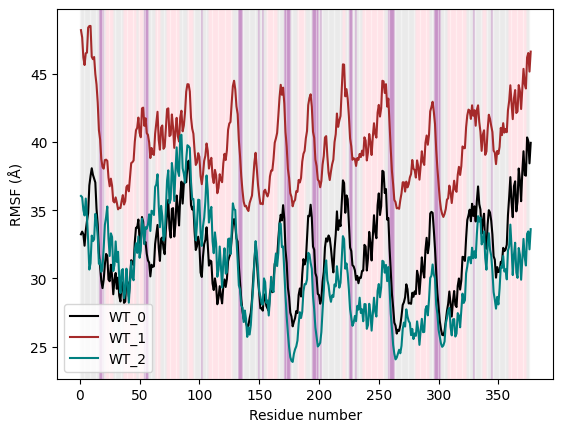

In [7]:
%matplotlib inline

# Colors for annotating with secondary structure
colors = {
    'H': 'pink',      # helix
    'E': 'purple',     # sheet
    '-': 'lightgray' # loop
}

# Plot RMSF of WT and other variants
plt.plot(c_alphas_WT_0_complete.resids,
         R_WT_0_complete.results.rmsf,
         color = 'black',
         label = 'WT_0'
         )
plt.plot(c_alphas_WT_1_complete.resids,
         R_WT_1_complete.results.rmsf,
         color = 'brown',
         label = 'WT_1'
         )
plt.plot(c_alphas_WT_2_complete.resids,
         R_WT_2_complete.results.rmsf,
         color = 'teal',
         label = 'WT_2'
         )

for i, ss in enumerate(avg_secondary_WT):
    plt.axvspan(i, i+1, color=colors[ss], alpha=0.15)

plt.xlabel('Residue number')
plt.ylabel('RMSF (Å)')
plt.legend()
plt.show()

First, the RMSF of all three predicted trajectories of the wildtype is compared. The plot shows that the three different trajectories differ quite a bit in RMSF, however the general patterns and thus the peaks and throughs seem to be quite similar. Albeit at a different amplitudes, suggesting that while the flexible and rigid regions are conserved, the extent of mobility in residues varies between the three trajectories. In order to compare this RMSF to that of mutant variants, I will first average the three RMSFs for WT. Instead of using the whole trajectory, I will switch to only using the final 50ns, because it will reduce the RMSF as it will not include the 'unfolding' of the protein at the start of the simulation (which is not necessarily part of how the protein moves under normal circumstances).

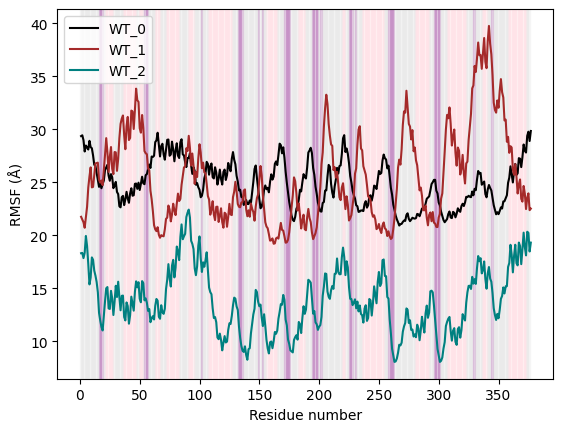

In [8]:
%matplotlib inline

# Plot RMSF of WT and other variants
plt.plot(c_alphas_WT_0.resids,
         R_WT_0.results.rmsf,
         color = 'black',
         label = 'WT_0'
         )
plt.plot(c_alphas_WT_1.resids,
         R_WT_1.results.rmsf,
         color = 'brown',
         label = 'WT_1'
         )
plt.plot(c_alphas_WT_2.resids,
         R_WT_2.results.rmsf,
         color = 'teal',
         label = 'WT_2'
         )

for i, ss in enumerate(avg_secondary_WT):
    plt.axvspan(i, i+1, color=colors[ss], alpha=0.15)

plt.xlabel('Residue number')
plt.ylabel('RMSF (Å)')
plt.legend()
plt.show()

As expected, the RMSF went down by quite a bit for all three trajectories, indicating that a lot of the mobility of the residues was caused by the unfolding of the protein from crystallized structure, to free protein in solvent. Notably, the peaks and throughs also seem less similar than when comparing the RMSF for the complete trajectories. This could indicate that the unfolding of the protein happened in a very similar manner for all three structures, and the noise was so large that it was those peaks and throughs that were noticed easily. WT_2 seems to have a lot lower RMSF than WT_1 and WT_0. WT_0 and WT_1 seem similar for the first 250 residues, after which the RMSF of WT_1 increases significantly. It is hard to say what trajectory would best predict real life HDAC8 dynamics, so I have decided to calculate an average using the three different RMSFs.

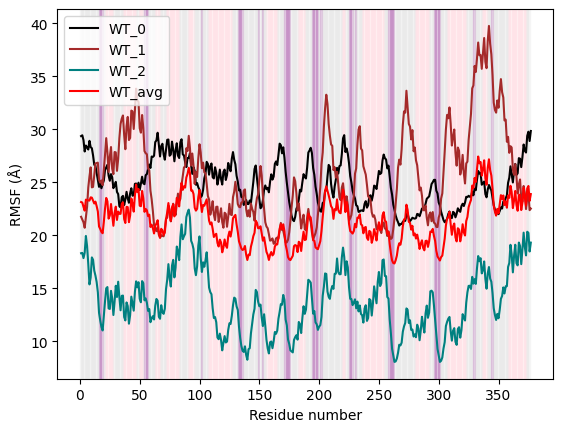

In [9]:
# Add all rmsf results together and divide by 3
avg_rmsf_WT = (R_WT_0.results.rmsf + R_WT_1.results.rmsf + R_WT_2.results.rmsf) / 3.0

# Plot RMSF of WT and other variants
plt.plot(c_alphas_WT_0.resids,
         R_WT_0.results.rmsf,
         color = 'black',
         label = 'WT_0'
         )
plt.plot(c_alphas_WT_1.resids,
         R_WT_1.results.rmsf,
         color = 'brown',
         label = 'WT_1'
         )
plt.plot(c_alphas_WT_2.resids,
         R_WT_2.results.rmsf,
         color = 'teal',
         label = 'WT_2'
         )

plt.plot(c_alphas_WT_0.resids,
         avg_rmsf_WT,
         color = 'red',
         label = 'WT_avg'
         )

for i, ss in enumerate(avg_secondary_WT):
    plt.axvspan(i, i+1, color=colors[ss], alpha=0.15)

plt.xlabel('Residue number')
plt.ylabel('RMSF (Å)')
plt.legend()
plt.show()


Above the average RMSF is shown in red, nicely located in the center of all three trajectories. This average RMSF will be used to compare to other variants. For the other variants I will also be using the average RMSF, based on the three trajectories for each variant.

In [10]:
avg_rmsf_G320R = (R_G320R_0.results.rmsf + R_G320R_1.results.rmsf + R_G320R_2.results.rmsf) / 3.0
avg_rmsf_H334R = (R_H334R_0.results.rmsf + R_H334R_1.results.rmsf + R_H334R_2.results.rmsf) / 3.0
avg_rmsf_T311M = (R_T311M_0.results.rmsf + R_T311M_1.results.rmsf + R_T311M_2.results.rmsf) / 3.0
avg_rmsf_H180R = (R_H180R_0.results.rmsf + R_H180R_1.results.rmsf + R_H180R_2.results.rmsf) / 3.0

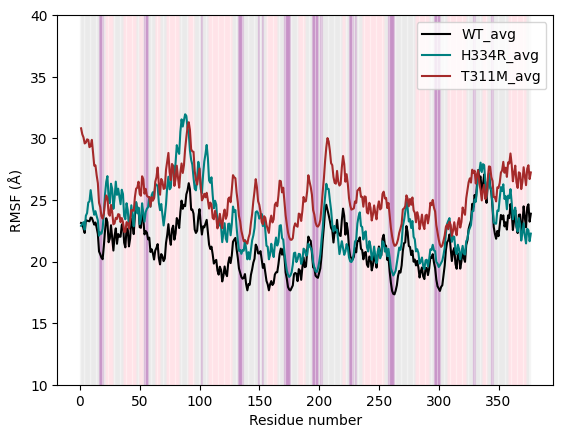

In [23]:
# Plot RMSF of WT and other variants
plt.plot(c_alphas_WT_0.resids,
         avg_rmsf_WT,
         color = 'black',
         label = 'WT_avg'
         )

plt.plot(c_alphas_H334R_0.resids,
         avg_rmsf_H334R,
         color = 'teal',
         label = 'H334R_avg'
         )
plt.plot(c_alphas_T311M_0.resids,
         avg_rmsf_T311M,
         color = 'brown',
         label = 'T311M_avg'
         )
plt.xlabel('Residue number')
plt.ylabel('RMSF (Å)')

for i, ss in enumerate(avg_secondary_WT):
    plt.axvspan(i, i+1, color=colors[ss], alpha=0.15)

plt.legend()
plt.ylim(10, 40)
plt.show()

In the plot above the avg WT RMSF is compared to that of H334R and T311M variants. The peaks and throughs seem very similar, in parts where WT is more mobile, the same goes for the mutant variants. So the mobile and less mobile regions are preserved, however, the RMSF seems to generally be quite a bit higher than that of the WT, especially in the case of T311M. Indicating that already mobile regions have become even more mobile and that less mobile regions have also become more mobile. This can lead to changes in protein shape and can possibly affect protein function.

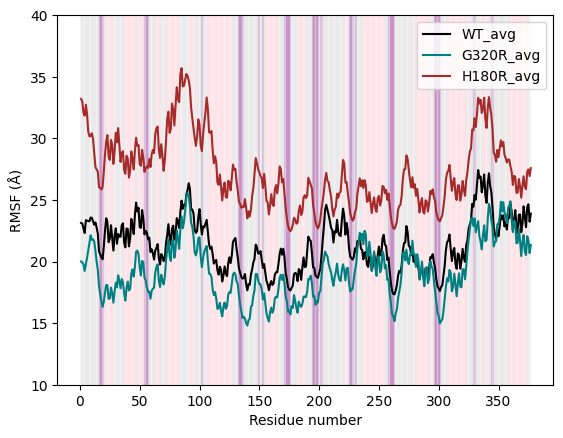

In [24]:
# Plot RMSF of WT and other variants
plt.plot(c_alphas_WT_0.resids,
         avg_rmsf_WT,
         color = 'black',
         label = 'WT_avg'
         )
plt.plot(c_alphas_G320R_0.resids,
         avg_rmsf_G320R,
         color = 'teal',
         label = 'G320R_avg'
         )
plt.plot(c_alphas_H180R_0.resids,
         avg_rmsf_H180R,
         color = 'brown',
         label = 'H180R_avg'
         )

for i, ss in enumerate(avg_secondary_WT):
    plt.axvspan(i, i+1, color=colors[ss], alpha=0.15)

plt.xlabel('Residue number')
plt.ylabel('RMSF (Å)')
plt.legend()
plt.ylim(10, 40)
plt.show()

Again the avg RMSF of the WT is compared, this time for mutant variants G320R and H180R. All three profiles seem to match very well, again having very similar peaks and throughs. However, mobility within residues seems to be lowered in G320R and very strongly elevated in H180R, which could have serious impact on protein shape and activity.

Looking at the annotation using the secondary structures, the RMSF seems to strongly decrease every time a sheet structure is encountered, this can be explained by the fact that sheets are more rigid than helixes and a far more rigid than loops. Every time loops are encountered, the RMSF can be seen spiking upwards.

### Distance Analysis

In this section, distances between the zinc ion, which plays a main role in catalytic activity, and other vital residues are determined. Including Y306, D178, H180, H142, H143 and D267, more about these residues can be read in the "Active Site" section. These distance calculations are done for all variants, including the WT. But first, distances from the mutationsite to the active site are determined below.

In [155]:
# Calculate dist from mutation to active site (Zn2+)
def dist_from_active_site(mutant, resid):
    zn = mutant.select_atoms("resid 378 and name ZN")
    site = mutant.select_atoms(resid)

    com1 = zn.center_of_mass()
    com2 = site.center_of_mass()
    dist = np.linalg.norm(com1-com2)

    return dist

mutant_dict = \
    { G320R_avg: ("G320R", "resid 320"),
      H180R_avg: ("H180R", "resid 180"),
      H334R_avg: ("H334R", "resid 334"),
      T311M_avg: ("T311M", "resid 311"),
      }

for mutant, (name, resid) in mutant_dict.items():
    dist = dist_from_active_site(mutant, resid)
    print(f"Distance from mutation {name} to active site: {round(dist, 2)}Å")


Distance from mutation G320R to active site: 22.59Å
Distance from mutation H180R to active site: 5.8Å
Distance from mutation H334R to active site: 30.7Å
Distance from mutation T311M to active site: 10.5Å


Mutation H180R seems to be the closest to the active site, with 5.8Å and H334R seems to be the mutation furthest away (30.7Å). It is likely that the distances to the active site play a role in how severe catalytic activity is affected. Seeing as H180R has 0% of remaining catalytic activity, and H334R 91%.

#### Dist between vital residues/Zn ion

In [7]:
# Calculate dist between any resid and Zn2+ ion, based on center of mass
def calculate_dist(universe, resid):
  cofactor = universe.select_atoms("resid 378 and name ZN")
  residue = universe.select_atoms(resid)

  dL = []
  for _ in universe.trajectory:
    com1 = cofactor.center_of_mass()
    com2 = residue.center_of_mass()
    dL.append(np.linalg.norm(com1-com2))

  return dL

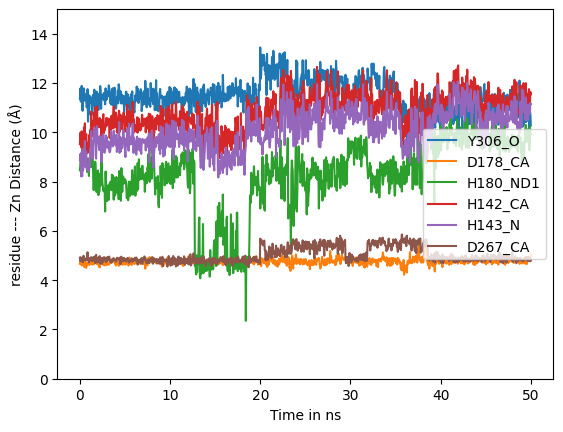

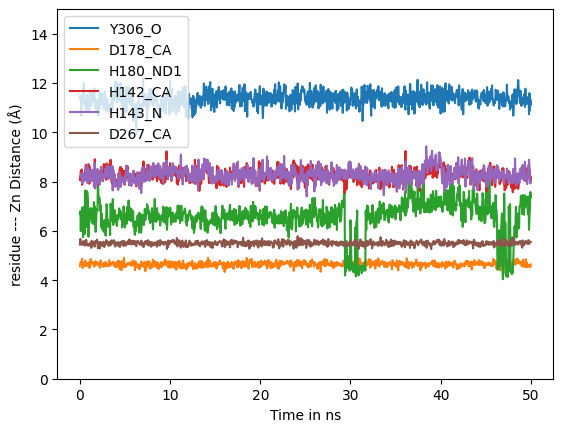

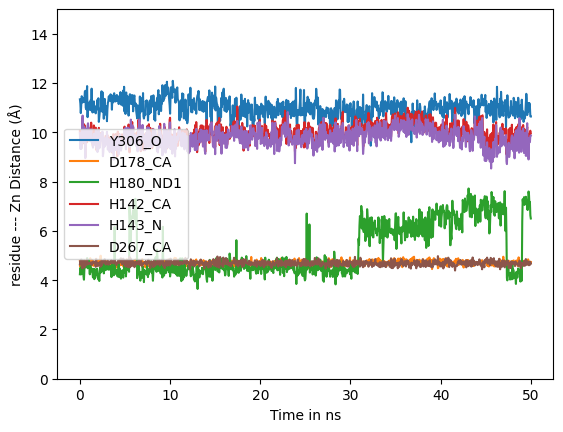

In [8]:
# Calculate dist between active site Zn2+ and vital residues for catalytic activity
def residue_zn_dist(variant):
    dL_variant_Y306 = calculate_dist(variant, "resid 306 and name O")
    dL_variant_D178 = calculate_dist(variant, "resid 178 and name CA")
    dL_variant_H180 = calculate_dist(variant, "resid 180 and name ND1")
    dL_variant_H142 = calculate_dist(variant, "resid 142 and name CA")
    dL_variant_H143 = calculate_dist(variant, "resid 143 and name N")
    dL_variant_D267 = calculate_dist(variant, "resid 267 and name CA")

    x = np.linspace(0, 50, len(dL_variant_Y306))

    plt.plot(x, dL_variant_Y306, label = "Y306_O")
    plt.plot(x, dL_variant_D178, label = "D178_CA")
    plt.plot(x, dL_variant_H180, label = "H180_ND1")
    plt.plot(x, dL_variant_H142, label = "H142_CA")
    plt.plot(x, dL_variant_H143, label = "H143_N")
    plt.plot(x, dL_variant_D267, label = "D267_CA")

    plt.ylabel("residue --- Zn Distance (Å)")
    plt.xlabel("Time in ns")
    plt.ylim(bottom=0, top=15)
    plt.legend()
    plt.show()

for variant in [WT_0, WT_1, WT_2]:
    residue_zn_dist(variant)

The plots above show the distance between vital residues of the active site and the Zn ion, for the three different predicted trajectories of the wildtype. There seem to be very large differences across the 3 plots. WT_0 seems to have a larger variance in distances than WT_1 and WT_2. The most consistent distances seem to be those between Zn and D267_CA, D178_CA and Y306_O. Distances to H180_ND1, H142_CA and H143_N seem to strongly fluctuate over time. In order to be able to compare distances among variants, the WT results first have to be averaged out.

In [9]:
def zn_dist_avg(universe):
    return {
        "Y306_O": calculate_dist(universe, "resid 306 and name O"),
        "D178_CA": calculate_dist(universe, "resid 178 and name CA"),
        "H180_ND1": calculate_dist(universe, "resid 180 and name ND1"),
        "H142_CA": calculate_dist(universe, "resid 142 and name CA"),
        "H143_N": calculate_dist(universe, "resid 143 and name N"),
        "D267_CA": calculate_dist(universe, "resid 267 and name CA"),
    }


In [10]:
WT0_dist = zn_dist_avg(WT_0)
WT1_dist = zn_dist_avg(WT_1)
WT2_dist = zn_dist_avg(WT_2)

avg_WT_dist = {}

for key in WT0_dist.keys():
    avg_WT_dist[key] = (
        np.array(WT0_dist[key]) +
        np.array(WT1_dist[key]) +
        np.array(WT2_dist[key])
    ) / 3.0

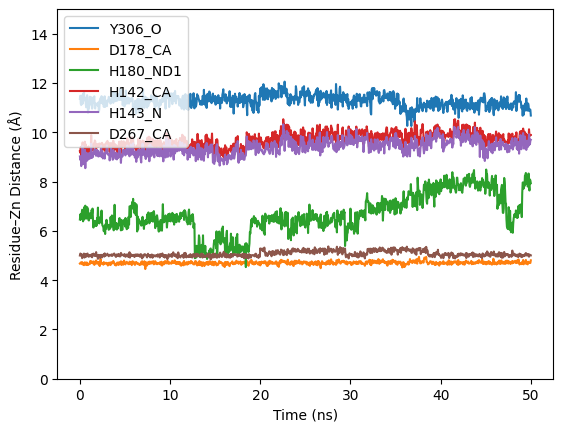

In [11]:
x = np.linspace(0, 50, len(avg_WT_dist["Y306_O"]))

plt.plot(x, avg_WT_dist["Y306_O"], label="Y306_O")
plt.plot(x, avg_WT_dist["D178_CA"], label="D178_CA")
plt.plot(x, avg_WT_dist["H180_ND1"], label="H180_ND1")
plt.plot(x, avg_WT_dist["H142_CA"], label="H142_CA")
plt.plot(x, avg_WT_dist["H143_N"], label="H143_N")
plt.plot(x, avg_WT_dist["D267_CA"], label="D267_CA")

plt.ylabel("Residue–Zn Distance (Å)")
plt.xlabel("Time (ns)")
plt.ylim(0, 15)
plt.legend()
plt.show()


The resulting distance plot now shows the average over the 3 WT trajectories. D178_CA and D267_CA seem to have a stable distance to Zn, with a small variance. This is expected as these are the two residues coordinating zinc. Y306_O, H142_CA and H143_N also seem to have a larger distance to Zn, but this distance remains mostly the same over time. H180_ND1 by far has the highest variance in distance and seems to move closer to- and away from the Zn ion. The residue at H180 coordinates the Zn ion, like D178 and D267 and H180 also helps form the structure of the tunnel. It seems that movement of H180 over time, closer and further away from the Zn ion, is needed for proper catalytic activity.

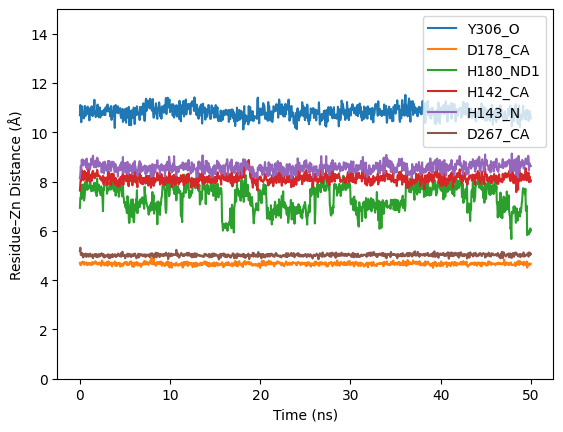

In [12]:
G320R_0_dist = zn_dist_avg(G320R_0)
G320R_1_dist = zn_dist_avg(G320R_1)
G320R_2_dist = zn_dist_avg(G320R_2)

avg_G320R_dist = {}

# third trajectory seems to be 3 frames shorter
for key in G320R_0_dist.keys():
    avg_G320R_dist[key] = (
        np.array(G320R_0_dist[key])[:997] +
        np.array(G320R_1_dist[key])[:997] +
        np.array(G320R_2_dist[key])
    ) / 3.0

x = np.linspace(0, 50, len(avg_G320R_dist["Y306_O"]))

plt.plot(x, avg_G320R_dist["Y306_O"], label="Y306_O")
plt.plot(x, avg_G320R_dist["D178_CA"], label="D178_CA")
plt.plot(x, avg_G320R_dist["H180_ND1"], label="H180_ND1")
plt.plot(x, avg_G320R_dist["H142_CA"], label="H142_CA")
plt.plot(x, avg_G320R_dist["H143_N"], label="H143_N")
plt.plot(x, avg_G320R_dist["D267_CA"], label="D267_CA")

plt.ylabel("Residue–Zn Distance (Å)")
plt.xlabel("Time (ns)")
plt.ylim(0, 15)
plt.legend()
plt.show()

#### G320R

In the plot above all average distances from key residues to Zn ion are visualized over the final 50ns. Distances of Y306, D178 and D267 do not seem affected by mutation G320R. Distances of H142 and H143 seem to have been reduced, compared to the WT. Distance of H180 seems strongly affected, including a change in movement patterns. In WT the residue would move closer to Zn and then further away again, which is possibly related to proper catalytic functioning. In G320R however H180 stays at a further distance, also moving closer and further in a more frantic pattern.

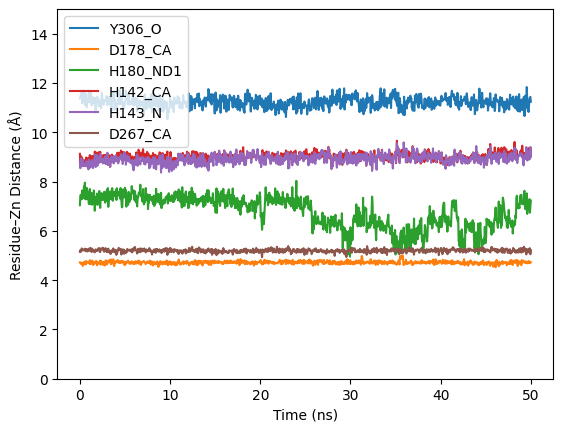

In [31]:
T311M_0_dist = zn_dist_avg(T311M_0)
T311M_1_dist = zn_dist_avg(T311M_1)
T311M_2_dist = zn_dist_avg(T311M_2)

avg_T311M_dist = {}

for key in T311M_0_dist.keys():
    avg_T311M_dist[key] = (
        np.array(T311M_0_dist[key]) +
        np.array(T311M_1_dist[key]) +
        np.array(T311M_2_dist[key])
    ) / 3.0

x = np.linspace(0, 50, len(avg_T311M_dist["Y306_O"]))

plt.plot(x, avg_T311M_dist["Y306_O"], label="Y306_O")
plt.plot(x, avg_T311M_dist["D178_CA"], label="D178_CA")
plt.plot(x, avg_T311M_dist["H180_ND1"], label="H180_ND1")
plt.plot(x, avg_T311M_dist["H142_CA"], label="H142_CA")
plt.plot(x, avg_T311M_dist["H143_N"], label="H143_N")
plt.plot(x, avg_T311M_dist["D267_CA"], label="D267_CA")

plt.ylabel("Residue–Zn Distance (Å)")
plt.xlabel("Time (ns)")
plt.ylim(0, 15)
plt.legend()
plt.show()

#### T311M

In the plot above all average distances from key residues to Zn ion are visualized over the final 50ns. Distances of D178 and D267 again do not seem affected by the mutation.
H142, H143 and Y306 seem to have gotten a smaller range of movement, as the variance in distance to Zn has gotten slightly smaller. The movement pattern of H180 seems similar to that of the WT, with a similar variance in distance to Zn. In general, for T311M all patterns seem fairly comparable to that of the WT, however T311M only has 6% of remaining catalytic activity, suggesting the cause lies somewhere else.

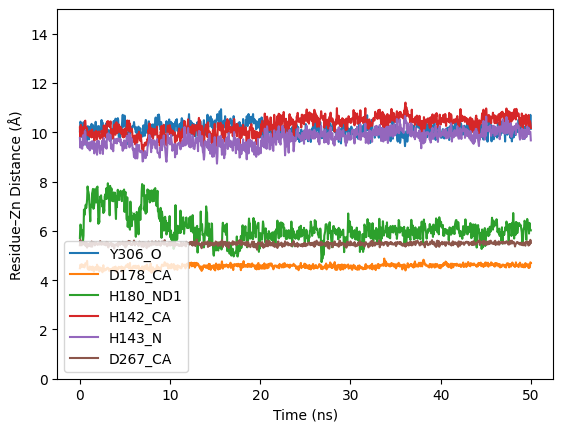

In [13]:
H334R_0_dist = zn_dist_avg(H334R_0)
H334R_1_dist = zn_dist_avg(H334R_1)
H334R_2_dist = zn_dist_avg(H334R_2)

avg_H334R_dist = {}

for key in H334R_0_dist.keys():
    avg_H334R_dist[key] = (
        np.array(H334R_0_dist[key]) +
        np.array(H334R_1_dist[key]) +
        np.array(H334R_2_dist[key])
    ) / 3.0

x = np.linspace(0, 50, len(avg_H334R_dist["Y306_O"]))

plt.plot(x, avg_H334R_dist["Y306_O"], label="Y306_O")
plt.plot(x, avg_H334R_dist["D178_CA"], label="D178_CA")
plt.plot(x, avg_H334R_dist["H180_ND1"], label="H180_ND1")
plt.plot(x, avg_H334R_dist["H142_CA"], label="H142_CA")
plt.plot(x, avg_H334R_dist["H143_N"], label="H143_N")
plt.plot(x, avg_H334R_dist["D267_CA"], label="D267_CA")

plt.ylabel("Residue–Zn Distance (Å)")
plt.xlabel("Time (ns)")
plt.ylim(0, 15)
plt.legend()
plt.show()

#### H334R

In the plot above all average distances from key residues to Zn ion are visualized over the final 50ns. This mutation is the first where there is a noticeable change in distance to D267/D178, suggesting coordination of the Zn ion might be altered. D178 again seems the same as for the WT. Y306 now seems significantly closer to the Zn ion and H142 and H143 seem a bit further away, making that all three residues now have a similar distance to Zn. The movement pattern (in distance) of H180 seems very altered, with the residue starting at a far distance, then coming closer to Zn and then staying at this close confirmation. However in WT H180 switches between far away from Zn and closer to Zn.

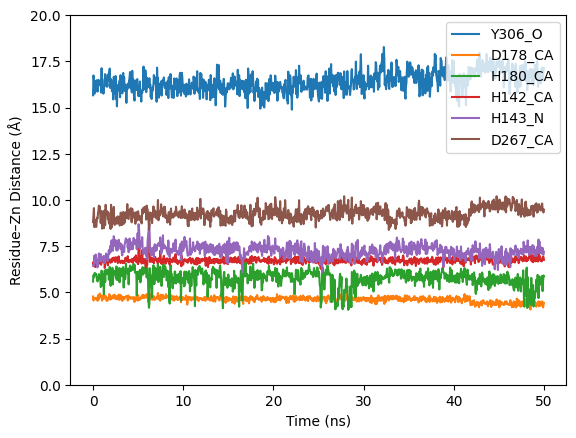

In [21]:
# H180R has to be done seperately as there is no ND1

def zn_dist_avg_H180R(universe):
    return {
        "Y306_O": calculate_dist(universe, "resid 306 and name O"),
        "D178_CA": calculate_dist(universe, "resid 178 and name CA"),
        "H180_CA": calculate_dist(universe, "resid 180 and name CA"),
        "H142_CA": calculate_dist(universe, "resid 142 and name CA"),
        "H143_N": calculate_dist(universe, "resid 143 and name N"),
        "D267_CA": calculate_dist(universe, "resid 267 and name CA"),
    }

H180R_0_dist = zn_dist_avg_H180R(H180R_0)
H180R_1_dist = zn_dist_avg_H180R(H180R_1)
H180R_2_dist = zn_dist_avg_H180R(H180R_2)

avg_H180R_dist = {}

for key in H180R_0_dist.keys():
    avg_H180R_dist[key] = (
        np.array(H180R_0_dist[key]) +
        np.array(H180R_1_dist[key]) +
        np.array(H180R_2_dist[key])
    ) / 3.0


x = np.linspace(0, 50, len(H180R_0_dist["Y306_O"]))

plt.plot(x, H180R_0_dist["Y306_O"], label="Y306_O")
plt.plot(x, H180R_0_dist["D178_CA"], label="D178_CA")
plt.plot(x, H180R_0_dist["H180_CA"], label="H180_CA")
plt.plot(x, H180R_0_dist["H142_CA"], label="H142_CA")
plt.plot(x, H180R_0_dist["H143_N"], label="H143_N")
plt.plot(x, H180R_0_dist["D267_CA"], label="D267_CA")

plt.ylabel("Residue–Zn Distance (Å)")
plt.xlabel("Time (ns)")
plt.ylim(0, 20)
plt.legend()
plt.show()


#### H180R
The residue-Zn distance seems completely altered compared to the WT. The distance between Zn and Y306 has increased by more than 5 Å. A different scale had to be used because of that, all other plots are stopped at 15, but this one had to be increased to 20. D367, which coordinates Zn, seemed very stable in all other mutations, but now has doubled in distance to Zn, meaning it can likely not do its job anymore of coordinating Zn. H142 and H143 are closer to the Zn ion. The movement pattern of H180 seems similar, but now closer to the Zn ion and less drastic changes are seen in switching between distant and close conformations to Zn. Out of all mutations H180R by far has the most deviating distances of key residues to Zn, indicating that the integrity of the active site has been lost due to the mutation of H180, which seems logical because H180 is part of the active site.

Text(0, 0.5, 'Distance (Å)')

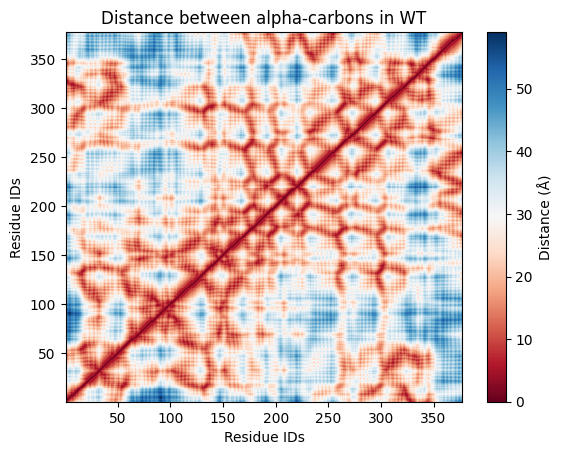

In [37]:
ca1 = WT_avg.select_atoms('name CA')
n_ca1 = len(ca1)

self_distances = distances.self_distance_array(ca1.positions)
sq_dist_arr = np.zeros((n_ca1, n_ca1))
triu = np.triu_indices_from(sq_dist_arr, k=1)
sq_dist_arr[triu] = self_distances
sq_dist_arr.T[triu] = self_distances

fig, ax = plt.subplots()
im = ax.pcolor(ca1.resids, ca1.resids, sq_dist_arr)

plt.set_cmap("RdBu")
plt.ylabel('Residue IDs')
plt.xlabel('Residue IDs')
plt.title('Distance between alpha-carbons in WT')
cbar = fig.colorbar(im)
cbar.ax.set_ylabel('Distance (Å)')


Text(0, 0.5, 'Distance (Å)')

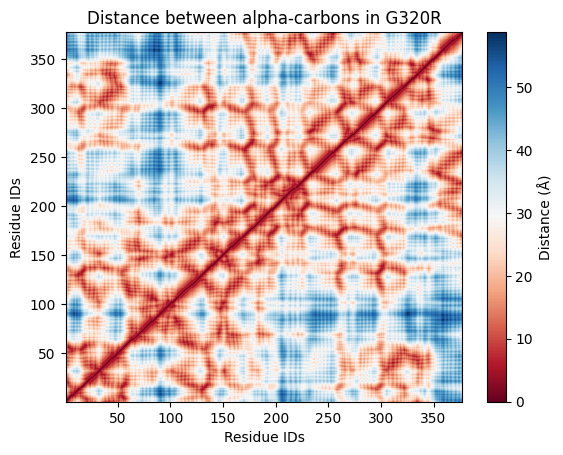

In [38]:
ca2 = G320R_avg.select_atoms('name CA')
n_ca2 = len(ca2)

self_distances = distances.self_distance_array(ca2.positions)
sq_dist_arr = np.zeros((n_ca2, n_ca2))
triu = np.triu_indices_from(sq_dist_arr, k=1)
sq_dist_arr[triu] = self_distances
sq_dist_arr.T[triu] = self_distances

fig, ax = plt.subplots()
im = ax.pcolor(ca2.resids, ca2.resids, sq_dist_arr)

# add figure labels and titles
plt.set_cmap("RdBu")
plt.ylabel('Residue IDs')
plt.xlabel('Residue IDs')
plt.title('Distance between alpha-carbons in G320R')

# colorbar
cbar = fig.colorbar(im)
cbar.ax.set_ylabel('Distance (Å)')

The heatmaps above demonstrate the distances within the protein, between residues. The heatmaps are nice for observing things such as the secondary structures, e.g. the hexagonal patterns that display distance patterns of alpha helices. However, these heatmaps are not suited for comparing mutations to the WT, as the general structure of the proteins stays the same, having only a singular mutation. The differences in distance are not clearly noticeable in the heatmap and thus I will make heatmaps showing the delta difference between WT and mutation


is difficult to determine the difference in distance between alpha carbons between WT and G320R, as alpha carbons are more stabile and thus will likely not be that affected by a mutation. For this reason we will look at the delta distance between alpha carbons between the two variants.

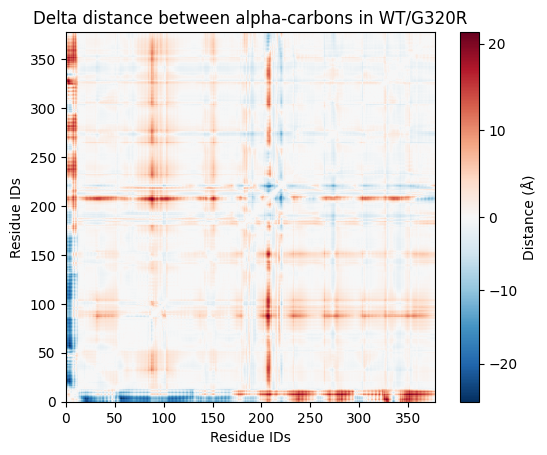

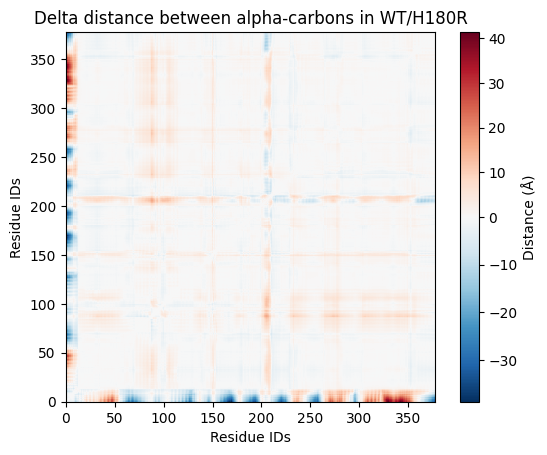

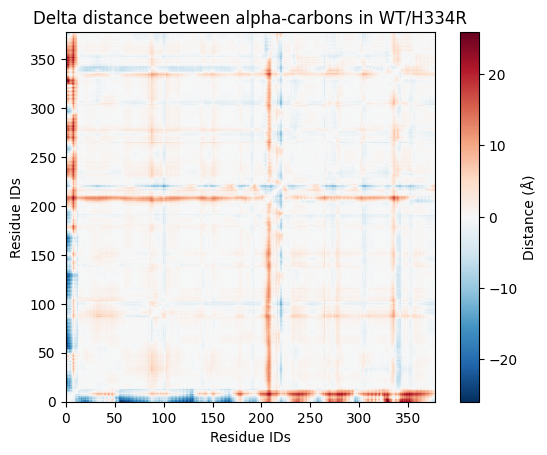

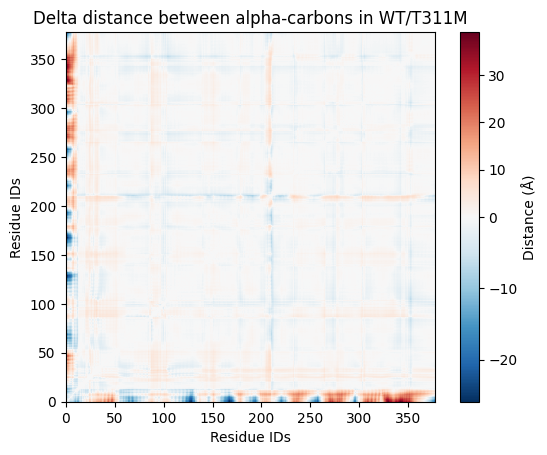

In [33]:

def delta_dist_WT_mutant(mutant, name):
    ca1 = WT_avg.select_atoms("name CA")
    ca2 = mutant.select_atoms("name CA")

    # pairwise distances
    distances_1 = distances.self_distance_array(ca1.positions)
    distances_2 = distances.self_distance_array(ca2.positions)

    N = len(ca1)
    M1 = np.zeros((N, N))
    M2 = np.zeros((N, N))

    triu = np.triu_indices(N, k=1)

    M1[triu] = distances_1
    M1.T[triu] = distances_1

    M2[triu] = distances_2
    M2.T[triu] = distances_2

    delta = M2 - M1  # Diff between coordinates of WT and mutant

    fig, ax = plt.subplots()
    im = ax.pcolor(ca1.resids, ca1.resids, delta)

    # Make heatmap square
    ax.set_aspect('equal')

    norm = TwoSlopeNorm(vmin=delta.min(), vcenter=0, vmax=delta.max())
    plt.set_cmap("RdBu_r")
    pc = plt.pcolormesh(delta, norm=norm, cmap="RdBu_r")
    plt.colorbar(pc, label="Distance (Å)", extendrect=False)

    # add figure labels and titles
    plt.ylabel('Residue IDs')
    plt.xlabel('Residue IDs')
    plt.title(f'Delta distance between alpha-carbons in WT/{name}')
    plt.show()

mutant_dict = {G320R_avg:"G320R", H180R_avg:"H180R", H334R_avg:"H334R", T311M_avg:"T311M"}

for mutant in mutant_dict:
    delta_dist_WT_mutant(mutant, mutant_dict[mutant])


Looking at the four heatmaps above, the Δdifference in alpha-carbon position can be seen over the average configuration of the last 50ns of the simulation. The distance is measured in Ångström and a red color means that the alpha-carbons of two residues were closer together than in the WT. A blue color means the opposite, the alpha-carbons of two residues were further away from eachother compared to the WT.

#### WT/G320R
Most of the residues seem to be further away from eachother compared to the WT. Especially residue ~210 seems to have an increased distance of 10-20 Å with most other residues, leading to a distinct 'cross-shaped' line in the heatmap. There seems to be another `line` that has formed, around residue 90, all other residues seem to have moved 5-20 Å further away. The distinct cross-shape could point towards there being more than one structural domain. According to literature and also the [UniProt entry for HDAC8](https://www.uniprot.org/uniprotkb/Q9BY41/entry#family_and_domains), the protein only has one defined domain, from residue 14 to 324. But what the heatmap shows looks like there are 2 or more separate domains in this mutation.

Around the lower part there seems to be quite some noise, residue ~1-15 seems to have moved closer to the first ~160 residues and further away from the residues that follow after. This could be explained by pure coincidence, as this is a loop at the very start of the protein and it likely moves a lot as it does not have a set structure. Residue 1-14 were also not taken into account for further analysis in the PCA, to reduce noise.


#### WT/H180R
Similar shapes and patterns to WT/G320R can be found in this heapmap. The cross-shape is again visible, however this time a lot lighter in color, indicating the different domains theory is perhaps less applicable for this mutation. In general the rest of the heatmap also seems lighter in color compared to G320R, meaning that the positions of alpha carbons seems less affected by the H180R mutation. This is unexpected, as both H180R and G320R have little to no remaining catalytic activity, so it would be expected that both differ quite a bit in structure to the WT. A hypothesis could be that the mutation of residue 180, which lies in the active site, only led to local changes, which results in a protein with a nearly identical structure to WT, but without catalytic activity.

#### WT/H334R
2 distinct lines seem visible, the line causing the cross-shape as seen in the other mutations and a secondary cross-shape that becomes visible as a result of residue ~220 moving closer to all other residues. None of the other mutations had this very clear double cross-shape, where one is further away and the one next to it is closer. This could indicate some sort of 'pulling' motion, that where residue ~210 moves further away, residue ~220 moves closer. H334R has almost full remaining catalytic activity (91%) which is noteworthy, as the Δdistances of alpha carbons seems to differ quite a bit to the WT, even in a part of the active site (which mostly takes place between ~140 and ~306).


#### WT/T311M
It is very clear that within the histone deacetylase domain (almost) every residue is closer to (almost) all other residues, compared to WT. This is quite interesting, as this means the entire protein became more compact as a result of the mutation. The same two distinct cross-shaped lines as in G320R can be seen in this mutation too.

## PCA
PCA (Principal Component Analysis) was performed on each of the variants, one PCA including all atoms and one including only key components to the catalytic activity of HDAC8. Both PCA's were done on 3 different simulations at once, meaning 3 different structures as predicted by AlphaFold and their corresponding trajectories as simulated by GROMACS. This was done to be able to provide more certainty that certain movements that were observed in the proteins are not purely caused by chance.


### PCA of entire protein
For the PCA of the entire protein the script below was used. 0, 1 and 2 stand for the different structures/trajectories. The input structures are all generated using the SnakeMake pipeline on the GROMACS output data. Hydrogen atoms were removed as they move a lot which can result in noise in the PCA. The structures are fitted twice, first they are fitted internally using `intra_fit` and next all three are fitted onto each other, using `extra_fit`. Fitting was only done on alpha carbons (ca), also known as the backbone of the protein. Residues 1-15 were excluded, as they added a lot of noise, as it was a loop structure at the very beginning of the protein. When fitting the structures onto each other, all secondary structure loops were excluded, as they move a lot. The results of the fitting will have a smaller RMSD when only fitted on more stable structures, including the alpha helixes and beta sheets.

PCA was performed on the final 1000 frames of the simulation, which is a total of 50ns. The first part of the simulation mostly consists of the protein unfolding from crystallized state, to its true state in a solvent. For performing the PCA `princomp.py` was used, a script made by my lecturer Tsjerk Wassenaar (not published yet).

```
load [variant]-0-ion.pdb, [variant]-0
load [variant]-0-ion.xtc, [variant]-0

load [variant]-1-ion.pdb, [variant]-1
load [variant]-1-ion.xtc, [variant]-1

load [variant]-2-ion.pdb, [variant]-2
load [variant]-2-ion.xtc, [variant]-2

remove hydro

intra_fit [variant]-0 and n. ca and not i. 1-14
intra_fit [variant]-1 and n. ca and not i. 1-14
intra_fit [variant]-2 and n. ca and not i. 1-14

# align the three different simulations
extra_fit not ss L

run princomp.py

# only perform PCA on final 1000 frames (= final 50 ns)
P=Princomp("not i. 1-14", frames=slice(4002,-1))

# violin plot
P[1].violin().draw("pc1violin")
P[2].violin().draw("pc2violin")

P[1].violin().recolor(x=P[1].scores, y=P.data.states).draw("pc1time")
P[2].violin().recolor(x=P[2].scores, y=P.data.states).draw("pc2time")

P.drawmean()
show cartoon, pcmean
hide lines
spectrum resi, grey30_grey90, pcmean
set cartoon_fancy_helices,
show spheres, pcmean and ele zn
```

#### WT

For analysis, I focused on the first two components (PC1/PC2), as they describe the majority of movements that take place.


|           | RMSD               |
|-----------|--------------------|
| WT-0/WT-1 | 0.997 (2060 atoms) |
| WT-0/WT-2 | 0.876 (2186 atoms) |


**PC1**

![](imgs/WT_PCA1.png)
![](imgs/WT_PCA1_2.png)





Most of the movement of PC1 seems to take place in the structures above the active site. On the left the moving structure consists of a loop (res 204-212) and on the right it consists of a loop and an alpha helix (75-101). The movement shows some kind of in/out configuration where both structures move either inwards towards the active site or outwards, away from the active site. Other than these two movements no other significant movements can be seen in PC1.

![](imgs/G320R_PCA1_time.png)

From the images above, a clear rotating movement can be seen from two different angles. Taking place in an alpha helix and surrounding loops (~ res 64-114). This rotating movement seems to be able to bring the helix inwards, towards the active site and also move away from it again.

**PC2**

![](imgs/WT_PCA2_2.png)



![](imgs/WT_PCA2.png)

From PC2, various movements can be seen. The same movement as PC1 is again shown in PC2, however this time the violin plots are perpendicular to those of PC1, signifying the actual direction of the movement. 2 other visible movements take place in loops, where they have a very distinct linear movement with little to no curve. The loops move inward/outward from the active site. The image clearly shows two structures that can move inwards/outwards.

![](imgs/WT_PCA2_3.png)


For the movement over time, blue and red signify start/endpoints. A constant change between configurations can be seen as a violet color. Most violin plots have a purple middle region, signifying that the protein can easily shift within these middle boundaries. At the ends of the violin plots, a (light) red color can be seen, signifying that the protein stops changing configurations once it reaches this point, or at least remain in this same configuration for an extended period of time.

![](imgs/WT_PCA2_time.png)


#### G320R

The three simulations were fitted onto eachother according to the preprocessing steps in the PyMol script above, resulting in:

|                | RMSD               |
|----------------|--------------------|
| G320R-0/G320R-1| 0.965 (2241 atoms) |
| G320R-0/G320R-2| 1.000 (2162 atoms) |


**PC1**

![](imgs/G320R_PCA1.png)


**PC2**

![](imgs/G320R_PCA2.png)

![](imgs/G320R_PCA2_2.png)

Most of the violin plots appear short, indicating that displacement was not that severe (likely because those movements were already captured in PC1). The movement patterns in general also seem smaller, as the violin plot no longer consists of 2 thick points at each end, connected by a very thin line in the middle. For the second component, many element movements involve 3 or 4 visible points where the configuration may be located.

One noticeable movement that can be seen, takes place around one of the alpha helices near the active site, including some surrounding loops (~res 64-114). The first image shows this movement from a side-view perspective, and the second image from a front facing perspective, with the active site centrally. It looks like a rotating motion that allows the helix to move closer to the active site and away from it, showing an "open"/"close" configuration. No other distinct movement patterns seem visible from the second component.

The rotation movement of WT PC1 was seen in G320R PC2, signifying that the movement that WT PC1 describes has gotten smaller for mutation G320R or that other movements have become larger.


#### T311M

|                | RMSD               |
|----------------|--------------------|
| T311M-0/T311M-1| 1.089 (2068 atoms) |
| T311M-0/T311M-2| 1.043 (2096 atoms) |


**PC1**

![](imgs/PCA_1_T311M.png)

Above the Zn ion, the same kind of rotating movement can be seen as in the two variants before, however in this variant it seems the movement is twisted and actually rotates into the side, instead of inwards to the active site. This could have effects on the different conformations or shapes that the protein can take. Some other strong movements can be seen in surrounding loop structures. These movements were not visible to this extent for the WT, so it is possible this mutation affects dynamics across multiple regions of the protein.

![](imgs/PCA_2_T311M.png)
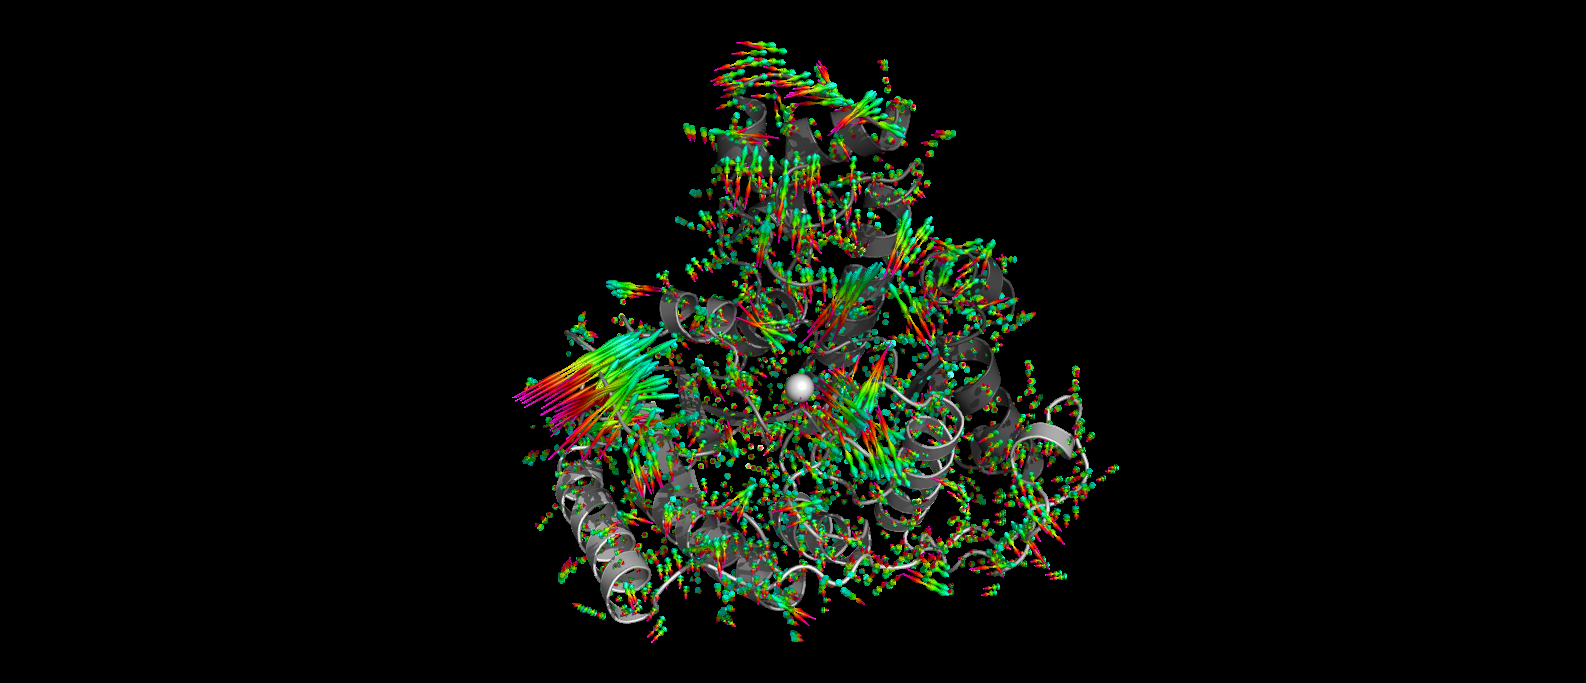

Again, for PC2, there are very strong movements for the surrounding loop structures. The region above the Zn ion shows some slight movement inwards, to the active site, but this movement seems a lot less strong than the sideways twisting movement as seen in PC1. When looking at both PCs at one there does not seem to be clear movements happening, a lot of movements happen perpendicular. However, when rotating the protein 90 degrees to the left, a clear rotating movement can be observed.

![](imgs/PCA_1_2_T311M.png)

Below the movement in the PCs is coloured over time, here it is clear that the movements seem to all contradict eachother from the active site "front view". The violin plots are again violet, indicating continuous movement back and forth.


![](imgs/T311M_time.png)


#### H334R


|                | RMSD               |
|----------------|--------------------|
| H334R-0/H334R-1| 0.818 (1995 atoms) |
| H334R-0/H334R-2| 0.905 (2151 atoms) |


**PC1**

![](imgs/PCA_1_H334R.png)

![](imgs/PCA_1_2_H334R.png)



Similar to PC1 of T311M, a sideways rotating movement can be seen in the helixes above the active site, this is again best seen when rotating the protein 90 degrees sideways. There seems to be quite a bit of movement in loops in other parts of the protein, but this can also be seen in other variants and in the WT.

**PC2**

![](imgs/PCA_2_H334R.png)

Compared to other variants, PC2 of H334R does not add a lot of movement, most of the movements are directly perpendicular to those of PC1. When adding the components together it becomes visible that it is hard to identify any clear movement patterns.

![](imgs/H334R_PCA12.png)


![](imgs/H334R_time.png)

Again the movement over time seems continuous as visible from the lilac colour of the violin plots, however, there seems to be an increase of blue colouring on the violinplot, as opposed to the other variants. Meaning this variant takes on certain conformations at the start of the simulation, but later strays away from them.
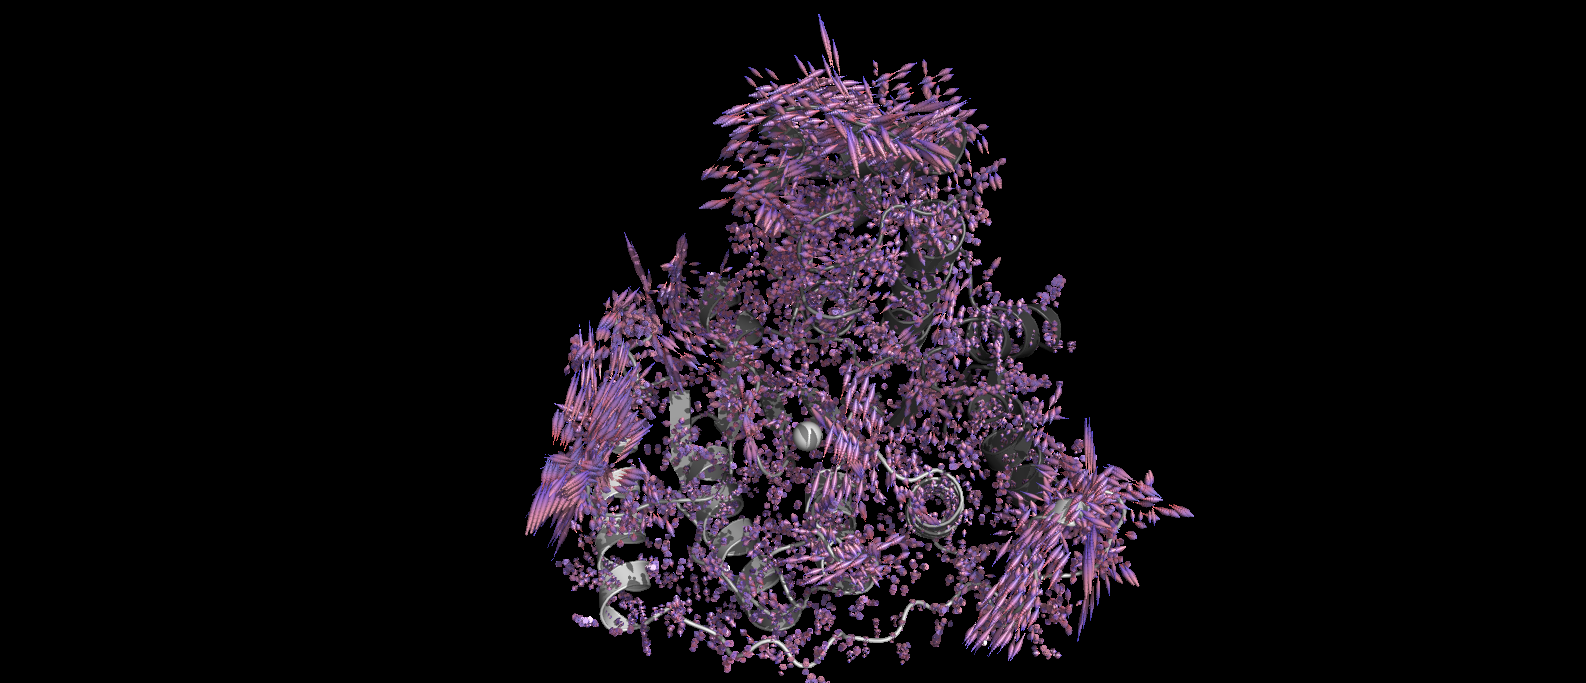

#### H180R

|                | RMSD               |
|----------------|--------------------|
| H180R-0/H180R-1| 0.970 (2165 atoms) |
| H180R-0/H180R-2|  1.194 (2211 atoms)|

**PC1**

![](imgs/H180R_PC1.png)
Out of all variants, PC1 of H180R seems to give the least visible movement patterns. There is no clear rotating pattern, just one small area above the catalytic site that turns to the right. Which is not comparable to any of the clear rotating patterns as seen in all other variants. This suggests clearly altered protein dynamics.


**PC2**

![](imgs/H180R_PC2.png)

For PC2 a pattern can be seen similar to T311M, with the structure above the active site turning in a sideways manner, instead of turning towards the active site like in the WT.

![](imgs/H180R_time.png)

Again the movement over time seems continuous as visible from the lilac colour of the violin plots.

### PCA of catalytic site

As the core components of the catalytic site are all embedded or enclosed in a cave-like structure, likely they do not have the space or capacity to be highly mobile, so to be able to notice minor differences in movement the noise of all other atoms of the protein was removed.

Below is the preprocessing that was also used to generate the image at the chapter discussing the structure.

```
load [variant]-0-ion.pdb, [variant]-0
load [variant]-0-ion.xtc, [variant]-0

load [variant]-1-ion.pdb, [variant]-1
load [variant]-1-ion.xtc, [variant]-1

load [variant]-2-ion.pdb, [variant]-2
load [variant]-2-ion.xtc, [variant]-2

remove hydro

intra_fit [variant]-0 and n. ca and not i. 1-14
intra_fit [variant]-1 and n. ca and not i. 1-14
intra_fit [variant]-2 and n. ca and not i. 1-14

# align the three different simulations
extra_fit not ss L

# select all core components
sele active_region, resi 142+143+151+152+176+178+180+183+208+267+274+306
label i. 306 and n. OH, resn + resi
label i. 267 and n. OD2, resn + resi
label i. 180 and n. ND1, resn + resi
label i. 143 and n. NE2, resn + resi
label i. 178 and n. OD1, resn + resi
label i. 274 and n. CE, resn + resi
label i. 152 and n. CE2, resn + resi
label i. 151 and n. CA, resn + resi
label i. 208 and n. CE1, resn + resi

```

Now we can continue with the PCA:

```
run princomp.py

# only perform PCA on final 1000 frames (= final 50 ns)
P=Princomp("active_region", frames=slice(4002,-1))

# violin plot
P[1].violin().draw("pc1violin")
P[2].violin().draw("pc2violin")

P[1].violin().recolor(x=P[1].scores, y=P.data.states).draw("pc1time")
P[2].violin().recolor(x=P[2].scores, y=P.data.states).draw("pc2time")

set cartoon_fancy_helices,
```

#### WT

![](imgs/WT_activesite_PCA.png)

The residues closest zo the Zn ion seem to only have very small movements, e.g Asp267, His180 and Asp178. Noteably all these residues play an important role in coordinating the Zn ion and maintaining the structure of the tunnel that leads to the active site. Suggesting that these residues are meant to be very rigid under 'healthy' circumstances. On the other hand, residues Phe208, Tyr306, Phe152, Met274 and Gly151 seem to have a large variance in conformations, suggesting that high mobility plays a role in their functioning. However, these residues are identified as residues that give structure to the tunnel, the high mobility might be necessary to allow ligands to enter.

The violin plots show the movements over time and the lilac color shows that the conformations switch around over time. Some parts show a more blue color, indicating this is the conformation as seen early-on in the time and more red looking parts indicate that that confirmation takes place later. For example the ends of the violin plot are a bit more red, indicating that later during the simulation, confirmation takes place at the end of violin plot.

#### G320R

![](imgs/PCA_G320R_active_site.png)

There seems to be a lot of movement taking place around the Zn ion, as opposed to for the WT where there was almost no movement directly around the Zn ion. This could affect catalytic activity, as Zn coordination and tunnel structure become less rigid. The violin plots are coloured lilac, meaning there are no specific preference configurations, the residues are constantly shifting back and forth over time.

#### T311M



![](imgs/T311M_activesite_PCA.png)

The movements of the active site of T311M seems very similar to those of the WT.


#### H334R

![](imgs/H334R_activesite_PCA.png)

The residues directly around the Zn ion seem to have comparable movement to the WT. However, the residues in the second layer of the active site seem to have a changed direction compared to the WT, possibly affecting the stability of the tunnel that leads to the catalytic site.

#### H180R

![](imgs/PCA_active_site_H180R.png)

A lot more movement seems to be happening around the Zn ion compared to the WT, where there was practically no movement in the residues directly around the ion. This can be explained by the fact that one of those less mobile proteins got mutated in this variant (H180 -> R), making the site less stable, causing other residues to also have more movement. Whereas in the WT, the protein had a preference over time for certain configurations, the entire violin plots are lilac coloured, indicating continuous movement in residues, switching between configurations.

## Conclusion

### Research question
My research question was: _what are the effects of the selected mutations on the structure and dynamics of HDAC8 and how does this relate to a (partial) loss-of-function_. Below, I have summarized all findings, and with that I aim to contribute to answering the research question. While a definitive conclusion may require further investigation, I hope to provide a foundation for understanding the structural and functional implications of these mutations.

### RMSF

The RMSF pattern seems similar for all variant structures regarding peaks and throughs. However, the RMSF as a whole seems elevated for H334R, T311M, and H180R. Indicating an increase in mobility within the protein. The RMSF seems slightly decreased in G320R compared to the WT, indicating a decrease in mobility within the protein.

### Distance Analysis
Distances of D178 and D267 remained equal to WT for variants G320R and T311M. In H334R D178 seems to have moved slightly further from Zn, and D267 slightly closer. In H180R D178 moved slightly closer and D267 a lot further away from Zn, this distance over time of D267 also shows a variance that is a lot higher than WT. Both residues play a role in Zn coordination, which suggests coordination of the Zn ion might be altered, contributing to loss of catalytic activity. Distance of Y306 remained equal to WT for G320R. In T311M the variance of Y306 has gotten smaller, indicating that the residue became more rigid. For H334R Y306 moved significantly closer to Zn and significantly further away for H180R. In G320R and H180R distances of H142/H143 were reduced, compared to WT.  While distances got larger in H334R. In T311M the variance decreased. H180 distance seems equal to WT in T311M. In H334R the movement pattern (in distance) of H180 seems very altered, with the residue starting at a far distance, then coming closer to Zn, and then staying at this close confirmation. For G320R H180 stays at a further distance, moving closer and further in a more frantic pattern compared to WT. In H180R, the variant with the H180 mutation, movement of H180 is also altered. The residue no longer varies between close/far configurations like in WT, but seems stuck at the close configuration instead.

Out of all mutations H180R by far has the most deviating distances of key residues to Zn, indicating that the integrity of the active site has been lost due to the mutation of H180, which seems logical because H180 is part of the active site. The least altered mutation, distance-wise, seems to be G320R. Which is not the variant with the highest remaining catalytic activity, because that is H334R. However, distance patterns seem very affected in H334, yet 91% activity does remain. This confirms that distances are not the only factor playing a role in catalytic activity.

**Distance heatmap**

Mutations along the sequence of HDAC8 seem to have an effect on the distance between residues, resulting in a change in coordination altogether. Across the different mutations, certain patterns can be found, such as the intricate cross-shaped lines caused by a singular residue that has shifted further or closer to (almost) all other residues.

### PCA

**Active site**

G320R and H180R seemed to have a strong increase in movements in residues directly around the Zn ion, with the function of coordinating the Zn ion and/or the tunnel. This could lead to instability of the active site and can thus explain the decrease in catalytic activity. These same 2 variants also had no distinct conformations, like the wildtype, where certain positions of residues are favoured. Meaning that the residues are constantly moving and not remaining in a set conformation. This, too, could contribute to lowered catalytic activity. In H334R, movements of the second layer of the active site have changed direction compared to the WT, possibly affecting the stability of the tunnel that leads to the catalytic site. The movements of the active site of T311M seem very similar to those of the WT, which makes it harder to explain the remaining catalytic activity of only 6% in T311M.

**Whole protein**

PCA of the wildtype showed a clear rotating pattern in the structure above the active site (75-101), with it being able to rotate into the active site and away from it. It also shows a loop (res 204-212) that can move towards the other structure/active site and away from it. Suggesting an open/close conformation for this protein. The rotating movement of the structure above the active site got smaller in G320R, changed direction in T311M and H334, and almost fully disappears in H180R. For the WT, there were clear conformations when colouring the violinplots over time, with red coloring at the ends of the plots, suggesting those confirmations are held onto for longer, later in the simulation. For all variants, the violinplots became more lilac than the WT, suggesting that clear conformations are not present and the protein is in constant movement instead. Only in G320R and T311M, the loop structure, which was seen to open/close in WT, seems to have similar movement patterns to WT. In H334R and H180R, the loop structure movement seems to take place in a different location and manner from that in WT.


## Reflection

Hereby, I will reflect on this course and the resulting model. I have really enjoyed this course as it allowed me to further explore the field of molecular dynamics. I noticed that I have gotten more familiar/comfortable with using PyMol, GROMACS, and libraries such as MDAnalysis. However, a challenging part for me was that when I delve into a topic, I like to learn all about it. That’s when I found out how complex and extensive this field really is, I felt a bit overwhelmed, but it made me really happy because this meant that every single day I learnt many new things and every week I could look back at my progress and think ‘wow I really learnt a lot this week, last week I didn’t know about any of this!’. Next month I start my internship, and while my internship will not be related to molecular dynamics, I am looking forward to showing the research that I was able to do to the people at the lab (as this project conveniently is strongly related to the research they do).

### Limitations

- As mentioned above, the field of molecular dynamics is very extensive. This project took approximately 3/4 weeks in total, and it was a bit challenging to consider the methods that can be applied to answer the research question. Methods and analysis I applied during this project include distance analysis, PCA (using PyMol), and RMSF/secondary structure analysis. If I had had extra time, I would have liked to look into more noteworthy structures of HDAC8. For this research, I looked into the key components of the active site, but of course, there are also other components outside of the active site that can affect catalytic activity. An example of this could be two loops, as mentioned in (Kunze et al., 2013). It could also have been interesting to look into the structure of HDAC8 with a phosphorylated Ser39 residue, as has been described in literature by Somoza et al. (2004). Simulations were run using this conformation, but sadly, a lack of time did not allow for further analysis.
- I felt that molecular dynamics data is a bit harder to interpret as opposed to workflows with e.g., genomics/transcriptomics, etc. Where working with numbers might be a bit easier than working with a lot of visuals, such as the PCA. I think learning how to interpret this kind of data also comes with experience. I believe the results I have can form a nice start for further research, but I am aware that at this point it is hard to make any definitive conclusions.
- Due to the limited project time, there was not much time to come up with a project proposal. I think if I had more time, I would have spent longer doing literature research into all discovered mutations so far and select the ones that have been least studied. For this project, I just selected all mutants as discussed in the article by Deardorff et al. (2012). A nice idea could have been to select mutants that display a gradient of remaining catalytic activity. Right now, all selected mutants have very low remaining catalytic activity, with 3 of them being (almost) 0% (T311M, G320R, and H180R), and the fourth mutation having high remaining catalytic activity of 91% (H334R). It might have been better to study variants that range from no remaining activity, to some, to quite a bit, to having almost full catalytic activity remaining.

I think that I did the most I could do for this project, given the time I had. I am satisfied with what came of the final product, but would have liked having a bit more time to really be able to thoroughly analyze all the results. I am I got to learn so many new things about the MD field in such a short time, and I also think HDAC8 was a very interesting protein to analyse. I think something that I can take into account, for example, during my internship, is to make sure that I have realistic expectations of how much I can do within a given time. I think this is a bit easier for an internship as we get one whole month for planning out the project and coming up with a detailed plan of approach.

# Sources
- Drazic, A., Myklebust, L. M., Ree, R., & Arnesen, T. (2016). The world of protein acetylation. Biochimica Et Biophysica Acta (BBA) - Proteins And Proteomics, 1864(10), 1372–1401. https://doi.org/10.1016/j.bbapap.2016.06.007
- De Ruijter, A. J., Van Gennip, A. H., Caron, H. N., Kemp, S., & Van Kuilenburg, A. B. (2003). Histone deacetylases (HDACs): characterization of the classical HDAC family. Biochemical Journal, 370(3), 737–749. https://doi.org/10.1042/bj20021321
- Deardorff, M. A., Bando, M., Nakato, R., Watrin, E., Itoh, T., Minamino, M., Saitoh, K., Komata, M., Katou, Y., Clark, D., Cole, K. E., De Baere, E., Decroos, C., Di Donato, N., Ernst, S., Francey, L. J., Gyftodimou, Y., Hirashima, K., Hullings, M., . . . Shirahige, K. (2012). HDAC8 mutations in Cornelia de Lange syndrome affect the cohesin acetylation cycle. Nature, 489(7415), 313–317. https://doi.org/10.1038/nature11316
- Bekker, Henk & Berendsen, Herman & Dijkstra, E.J. & Achterop, S. & Drunen, Rudi & van der Spoel, David & Sijbers, A. & Keegstra, H. & Reitsma, B. & Renardus, M.K.R.. (1993). Gromacs: A parallel computer for molecular dynamics simulations. Physics Computing. 92. 252-256.
- Brooks, B. R., Brooks, C. L., Mackerell, A. D., Nilsson, L., Petrella, R. J., Roux, B., Won, Y., Archontis, G., Bartels, C., Boresch, S., Caflisch, A., Caves, L., Cui, Q., Dinner, A. R., Feig, M., Fischer, S., Gao, J., Hodoscek, M., Im, W., . . . Karplus, M. (2009). CHARMM: The biomolecular simulation program. Journal Of Computational Chemistry, 30(10), 1545–1614. https://doi.org/10.1002/jcc.21287
- D.A. Case, H.M. Aktulga, K. Belfon, I.Y. Ben-Shalom, J.T. Berryman, S.R. Brozell, F.S. Carvahol, D.S. Cerutti, T.E. Cheatham, III, G.A. Cisneros, V.W.D. Cruzeiro, T.A. Darden, N. Forouzesh, M. Ghazimirsaeed, G. Giambaşu, T. Giese, M.K. Gilson, H. Gohlke, A.W. Goetz, J. Harris, Z. Huang, S. Izadi, S.A. Izmailov, K. Kasavajhala, M.C. Kaymak, I. Kolossv\'a ry, A. Kovalenko, T. Kurtzman, T.S. Lee, P. Li, Z. Li, C. Lin, J. Liu, T. Luchko, R. Luo, M. Machado, M. Manathunga, K.M. Merz, Y. Miao, O. Mikhailovskii, G. Monard, H. Nguyen, K.A. O'Hearn, A. Onufriev, F. Pan, S. Pantano, A. Rahnamoun, D.R. Roe, A. Roitberg, C. Sagui, S. Schott-Verdugo, A. Shajan, J. Shen, C.L. Simmerling, N.R. Skrynnikov, J. Smith, J. Swails, R.C. Walker, J. Wang, J. Wang, X. Wu, Y. Wu, Y. Xiong, Y. Xue, D.M. York, C. Zhao, Q. Zhu, and P.A. Kollman (2025), Amber 2025, University of California, San Francisco.
- De Lange, C. (1933). Surun type nouveau degeneration (typus Amestelodamensis). Arch Med Enfants, 36, 713-719.
- Kline, A. D., Moss, J. F., Selicorni, A., Bisgaard, A., Deardorff, M. A., Gillett, P. M., Ishman, S. L., Kerr, L. M., Levin, A. V., Mulder, P. A., Ramos, F. J., Wierzba, J., Ajmone, P. F., Axtell, D., Blagowidow, N., Cereda, A., Costantino, A., Cormier-Daire, V., FitzPatrick, D., . . . Hennekam, R. C. (2018). Diagnosis and management of Cornelia de Lange syndrome: first international consensus statement. Nature Reviews Genetics, 19(10), 649–666. https://doi.org/10.1038/s41576-018-0031-0
- Deardorff, M. A., Porter, N. J., & Christianson, D. W. (2016). Structural aspects of HDAC8 mechanism and dysfunction in Cornelia de Lange syndrome spectrum disorders. Protein Science, 25(11), 1965–1976. https://doi.org/10.1002/pro.3030
- Osko, J. D., Porter, N. J., Decroos, C., Lee, M. S., Watson, P. R., Raible, S. E., Krantz, I. D., Deardorff, M. A., & Christianson, D. W. (2020). Structural analysis of histone deacetylase 8 mutants associated with Cornelia de Lange Syndrome spectrum disorders. Journal Of Structural Biology, 213(1), 107681. https://doi.org/10.1016/j.jsb.2020.107681
- Decroos, C., Christianson, N. H., Gullett, L. E., Bowman, C. M., Christianson, K. E., Deardorff, M. A., & Christianson, D. W. (2015). Biochemical and Structural Characterization of HDAC8 Mutants Associated with Cornelia de Lange Syndrome Spectrum Disorders. Biochemistry, 54(42), 6501–6513. https://doi.org/10.1021/acs.biochem.5b00881
- Somoza, J. R., Skene, R. J., Katz, B. A., Mol, C., Ho, J. D., Jennings, A. J., Luong, C., Arvai, A., Buggy, J. J., Chi, E., Tang, J., Sang, B., Verner, E., Wynands, R., Leahy, E. M., Dougan, D. R., Snell, G., Navre, M., Knuth, M. W., . . . Tari, L. W. (2004). Structural Snapshots of Human HDAC8 Provide Insights into the Class I Histone Deacetylases. Structure, 12(7), 1325–1334. https://doi.org/10.1016/j.str.2004.04.012
- Vannini, A., Volpari, C., Filocamo, G., Casavola, E. C., Brunetti, M., Renzoni, D., Chakravarty, P., Paolini, C., De Francesco, R., Gallinari, P., Steinkühler, C., & Di Marco, S. (2004). Crystal structure of a eukaryotic zinc-dependent histone deacetylase, human HDAC8, complexed with a hydroxamic acid inhibitor. Proceedings Of The National Academy Of Sciences, 101(42), 15064–15069. https://doi.org/10.1073/pnas.0404603101
- Finnin, M. S., Donigian, J. R., Cohen, A., Richon, V. M., Rifkind, R. A., Marks, P. A., Breslow, R., & Pavletich, N. P. (1999). Structures of a histone deacetylase homologue bound to the TSA and SAHA inhibitors. Nature, 401(6749), 188–193. https://doi.org/10.1038/43710
- Decroos, C., Christianson, N. H., Gullett, L. E., Bowman, C. M., Christianson, K. E., Deardorff, M. A., & Christianson, D. W. (2015b). Biochemical and Structural Characterization of HDAC8 Mutants Associated with Cornelia de Lange Syndrome Spectrum Disorders. Biochemistry, 54(42), 6501–6513. https://doi.org/10.1021/acs.biochem.5b00881
- Decroos, C., Bowman, C. M., Moser, J. S., Christianson, K. E., Deardorff, M. A., & Christianson, D. W. (2014). Compromised Structure and Function of HDAC8 Mutants Identified in Cornelia de Lange Syndrome Spectrum Disorders. ACS Chemical Biology, 9(9), 2157–2164. https://doi.org/10.1021/cb5003762
- Kunze, M. B. A., Wright, D. W., Werbeck, N. D., Kirkpatrick, J., Coveney, P. V., & Hansen, D. F. (2013). Loop Interactions and Dynamics Tune the Enzymatic Activity of the Human Histone Deacetylase 8. Journal Of The American Chemical Society, 135(47), 17862–17868. https://doi.org/10.1021/ja408184x